# Notebook 1 — Data Overview

**Goal:** Load the CSV files from the pipeline, understand what the data looks like, check for missing values, and visualize the distributions.

This notebook explores the output of the robocode-autopilot pipeline — CSV files generated from battle recordings. We have three types of files:

- **ticks.csv** — One row per game tick (like a frame in a video). Each row records what the robot could observe at that moment: distances, velocities, angles, energy levels. **No per-battle constants here** — keeping ticks lean (every column ≈ 8 bytes × millions of rows).
- **waves.csv** — One row per detected opponent fire. A snapshot of bullet power, speed, the distance at which the bullet was fired, the maximum escape angle (MEA), and our lateral velocity at fire instant.
- **scores.csv** — One row per round. Records the round outcome (damage dealt/received, hit rates, win) **plus per-battle constants** (opponent identity hashes, battlefield dimensions, gun cooling rate, total rounds). The constants are identical across all rounds of a battle — deduplicate via `scores.drop_duplicates('battle_id')` if you only need the constants once.

> **What is a DataFrame?** Think of it like a spreadsheet. Rows are observations (one per game tick), columns are measurements (features like distance, velocity, etc.). pandas is the Python library that gives us these spreadsheet-like tools.
>
> **Why split per-battle constants out of ticks.csv?** A value that never changes across a battle (like `battlefield_width`) repeated 3,000 times per battle wastes ~24 KB per battle × thousands of battles. Putting it in scores.csv (≤35 rows/battle) and joining when needed costs ~280 bytes per battle. Use `attach_battle_constants(ticks, scores)` from `_loader` to merge them on demand.


In [ ]:
# --- Setup ---
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _loader import build_robot_index, load_stratified

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# --- Data sampling strategy ---
# The full dataset is ~20 GB of ticks.csv across ~1900 battles. Naive loading
# OOMs VS Code's notebook host. Strategy: STRATIFIED per-robot sampling —
# pick top-N most-played robots × N battles each × row-subsample each file.
# Numeric columns are downcast (float64→float32, int64→int32) to halve RAM.
# See `intuition/_loader.py` — same helper used by every notebook in this folder.
selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)

ticks  = load_stratified("ticks.csv",  selection, row_frac=0.20)
waves  = load_stratified("waves.csv",  selection)   # small, keep all rows
scores = load_stratified("scores.csv", selection)   # tiny, keep all rows

# Sanity check: rows per robot in ticks
print("\nRows per robot in ticks (top 5 / bottom 5):")
counts = ticks['robot_name'].value_counts()
print(counts.head(5).to_string())
print("...")
print(counts.tail(5).to_string())


Indexing CSV tree (one-time scan)...


Found 50 distinct robots across 3888 ticks.csv files.
Selected 50 robots (top by appearance count).


Loaded 150 ticks.csv files → 1,003,073 rows × 30 cols, 50 robots (~226.5 MB in RAM)


Loaded 150 waves.csv files → 281,447 rows × 10 cols, 50 robots (~43.5 MB in RAM)


Loaded 150 scores.csv files → 5,250 rows × 10 cols, 50 robots (~0.8 MB in RAM)

Rows per robot in ticks (top 5 / bottom 5):
robot_name
Firestarter 2.0f    54590
Domogled 1.2        40974
Diamond 1.8.22      33695
Tomcat 3.68         30806
DrussGT 3.1.7       28628
...
robot_name
deBroglie rev0108    15592
Cardigan 1.09        15519
Pris 0.92            15400
Toad 0.14t           15337
Holden 1.13a         15201


In [2]:
# --- Quick look at each DataFrame ---
print("=" * 60)
print("TICKS.CSV — one row per game tick per robot perspective")
print("=" * 60)
print(f"Shape: {ticks.shape[0]:,} rows × {ticks.shape[1]} columns")
print(f"\nColumn names:\n{list(ticks.columns)}")
print(f"\nData types:\n{ticks.dtypes}")
print(f"\nFirst 3 rows:")
ticks.head(3)

TICKS.CSV — one row per game tick per robot perspective
Shape: 1,003,073 rows × 30 columns

Column names:
['battle_id', 'round', 'tick', 'scan_available', 'distance', 'bearing_to_opponent_abs', 'opponent_dist_to_wall_min', 'our_gun_heat', 'ticks_since_scan', 'opponent_name_hash', 'opponent_energy', 'opponent_fired', 'opponent_fire_power', 'opponent_velocity', 'opponent_lateral_velocity', 'opponent_advancing_velocity', 'opponent_heading_delta', 'energy_ratio', 'our_lateral_velocity', 'our_dist_to_wall_min', 'opponent_wall_ahead_distance', 'opponent_inferred_gun_heat', 'opponent_lateral_direction', 'opponent_velocity_delta', 'opponent_is_decelerating', 'opponent_time_since_direction_change', 'opponent_angular_velocity', 'opponent_max_turn_rate', 'distance_norm', 'robot_name']

Data types:
battle_id                                object
round                                      int8
tick                                      int16
scan_available                             int8
distance  

,battle_id,round,tick,scan_available,distance,bearing_to_opponent_abs,opponent_dist_to_wall_min,our_gun_heat,ticks_since_scan,opponent_name_hash,...,opponent_wall_ahead_distance,opponent_inferred_gun_heat,opponent_lateral_direction,opponent_velocity_delta,opponent_is_decelerating,opponent_time_since_direction_change,opponent_angular_velocity,opponent_max_turn_rate,distance_norm,robot_name
0,01eb4461,13,590,1,435.042999,5.2709,101.514999,0.18,0,-89311343,...,447.277008,0.3227,1.0,0.0,0.0,166.0,0.016810,0.0698,0.4350,Shadow 3.83c
1,01eb4461,6,430,1,446.993988,0.6318,79.833000,0.88,0,-89311343,...,202.914001,0.6598,1.0,-2.0,1.0,88.0,0.008424,0.1222,0.4470,Shadow 3.83c
2,01eb4461,4,508,1,411.864014,4.2124,116.857002,0.00,0,-89311343,...,465.984985,0.9218,-1.0,0.0,0.0,56.0,-0.017574,0.0698,0.4119,Shadow 3.83c


In [3]:
print("=" * 60)
print("WAVES.CSV — one row per bullet fired")
print("=" * 60)
print(f"Shape: {waves.shape[0]:,} rows × {waves.shape[1]} columns")
print(f"\nColumn names:\n{list(waves.columns)}")
display(waves.head(3))

print("\n" + "=" * 60)
print("SCORES.CSV — one row per round")
print("=" * 60)
print(f"Shape: {scores.shape[0]:,} rows × {scores.shape[1]} columns")
print(f"\nColumn names:\n{list(scores.columns)}")
display(scores.head(3))

WAVES.CSV — one row per bullet fired
Shape: 281,447 rows × 10 columns

Column names:
['battle_id', 'round', 'tick', 'wave_bullet_power', 'wave_bullet_speed', 'wave_fire_distance', 'wave_mea', 'wave_flight_time', 'wave_lateral_velocity_at_fire', 'robot_name']


,battle_id,round,tick,wave_bullet_power,wave_bullet_speed,wave_fire_distance,wave_mea,wave_flight_time,wave_lateral_velocity_at_fire,robot_name
0,01eb4461,0,33,0.82,17.534,270.079987,0.473785,15.40,-7.930,Shadow 3.83c
1,01eb4461,0,47,0.56,18.312,267.968994,0.452107,14.63,-7.769,Shadow 3.83c
2,01eb4461,0,61,0.76,17.719,228.466995,0.468437,12.89,-7.607,Shadow 3.83c



SCORES.CSV — one row per round
Shape: 5,250 rows × 10 columns

Column names:
['battle_id', 'round', 'ticks_in_round', 'damage_dealt', 'damage_received', 'net_damage', 'our_hit_rate', 'opponent_hit_rate', 'win_rate', 'robot_name']


,battle_id,round,ticks_in_round,damage_dealt,damage_received,net_damage,our_hit_rate,opponent_hit_rate,win_rate,robot_name
0,01eb4461,0,752,65.449997,40.310001,25.139999,0.1346,0.1905,0.0,Shadow 3.83c
1,01eb4461,1,894,42.990002,21.379999,21.600000,0.0806,0.0556,0.0,Shadow 3.83c
2,01eb4461,2,730,16.600000,37.119999,-20.520000,0.0500,0.1053,0.0,Shadow 3.83c


## Section 3 — Descriptive Statistics

Here's what each number in `.describe()` means:

| Statistic | What it means | Analogy |
|-----------|---------------|---------|
| **count** | How many non-NaN values | How many times we actually measured this |
| **mean** | Sum of all values ÷ count. The "average" | If you split all the pizza equally, how much each person gets |
| **std** | Standard deviation — how spread out values are from the mean | Small std = everyone got similar amounts. Large std = some got a lot, some got little |
| **min** | Smallest value | The shortest kid in class |
| **25%** | 25th percentile — 25% of values are below this | A quarter of the class is shorter than this |
| **50%** | Median — the middle value when sorted. Not fooled by extremes | The kid right in the middle of the line when sorted by height |
| **75%** | 75th percentile — 75% of values are below this | Three quarters of the class is shorter than this |
| **max** | Largest value | The tallest kid in class |

The range between 25% and 75% is called the **IQR (Interquartile Range)** — it's the "middle half" of the data.

In [4]:
# --- Descriptive statistics for ticks.csv ---
print("TICKS.CSV — Descriptive Statistics")
print("=" * 60)
# Transpose so features are rows (easier to read with many columns)
display(ticks.describe().T.round(3))

print("\n\nWAVES.CSV — Descriptive Statistics")
print("=" * 60)
display(waves.describe().T.round(3))

print("\n\nSCORES.CSV — Descriptive Statistics")
print("=" * 60)
display(scores.describe().T.round(3))

TICKS.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,1003073.0,1.698400e+01,1.005800e+01,0.000000e+00,8.000000e+00,1.700000e+01,2.600000e+01,3.400000e+01
tick,1003073.0,6.500180e+02,7.299890e+02,0.000000e+00,2.390000e+02,4.770000e+02,7.460000e+02,6.253000e+03
scan_available,1003073.0,8.380000e-01,3.680000e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
distance,840854.0,4.622600e+02,1.021380e+02,3.600000e+01,3.988300e+02,4.596710e+02,5.232390e+02,8.594180e+02
bearing_to_opponent_abs,840854.0,3.123000e+00,1.772000e+00,0.000000e+00,1.557000e+00,3.084000e+00,4.704000e+00,6.283000e+00
opponent_dist_to_wall_min,840854.0,1.079510e+02,6.735100e+01,1.800000e+01,5.277500e+01,9.313000e+01,1.514520e+02,2.999990e+02
our_gun_heat,1003073.0,5.140000e-01,4.660000e-01,0.000000e+00,8.000000e-02,4.690000e-01,8.300000e-01,3.000000e+00
ticks_since_scan,1003073.0,1.197300e+01,3.258500e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.830000e+02
opponent_name_hash,1003073.0,-2.192412e+08,1.194038e+09,-2.147252e+09,-1.589488e+09,-8.931134e+07,5.856206e+08,2.038229e+09
opponent_energy,840854.0,4.871200e+01,3.126900e+01,0.000000e+00,2.066200e+01,4.737000e+01,7.619600e+01,1.299850e+02




WAVES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,281447.0,17.053,10.068,0.000,8.000,17.000,26.000,34.000
tick,281447.0,627.373,749.731,4.000,221.000,419.000,666.000,6093.000
wave_bullet_power,281447.0,1.302,0.783,0.100,0.400,1.830,1.950,3.000
wave_bullet_speed,281447.0,16.094,2.350,11.000,14.150,14.519,18.800,19.700
wave_fire_distance,281447.0,467.483,99.991,40.474,402.302,464.145,527.058,829.137
wave_mea,281447.0,0.534,0.082,0.418,0.440,0.584,0.601,0.814
wave_flight_time,281447.0,29.362,6.361,2.220,25.040,29.100,33.600,68.500
wave_lateral_velocity_at_fire,281447.0,0.020,5.792,-8.000,-5.931,0.000,5.956,8.000




SCORES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,5250.0,17.000,10.100,0.00,8.000,17.000,26.000,34.000
ticks_in_round,5250.0,955.308,575.233,341.00,704.000,808.000,972.000,6254.000
damage_dealt,5250.0,35.447,18.629,0.00,20.505,36.310,49.068,89.950
damage_received,5250.0,36.411,19.196,0.00,21.972,37.600,50.100,99.940
net_damage,5250.0,-0.965,28.425,-99.94,-22.600,-0.870,20.660,89.120
our_hit_rate,5250.0,0.111,0.056,0.00,0.075,0.107,0.143,0.500
opponent_hit_rate,5250.0,0.122,0.067,0.00,0.081,0.118,0.156,1.062
win_rate,5250.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000


## Section 4 — Distributions: Histograms

A **histogram** divides the range of values into bins (buckets), counts how many values fall in each bin, and draws bars. A tall bar means many data points have values in that range.

A **KDE curve** (Kernel Density Estimation) is a smoothed version of the histogram — instead of blocky bars, it draws a smooth curve that shows the overall shape of the distribution.

Things to look for:
- **Bell-shaped (normal):** Values cluster around the middle — most common in nature
- **Skewed:** Values pile up on one side. Right-skewed = long tail to the right
- **Bimodal:** Two peaks — might mean there are two different "modes" of play
- **Uniform:** Flat — values are equally likely across the range

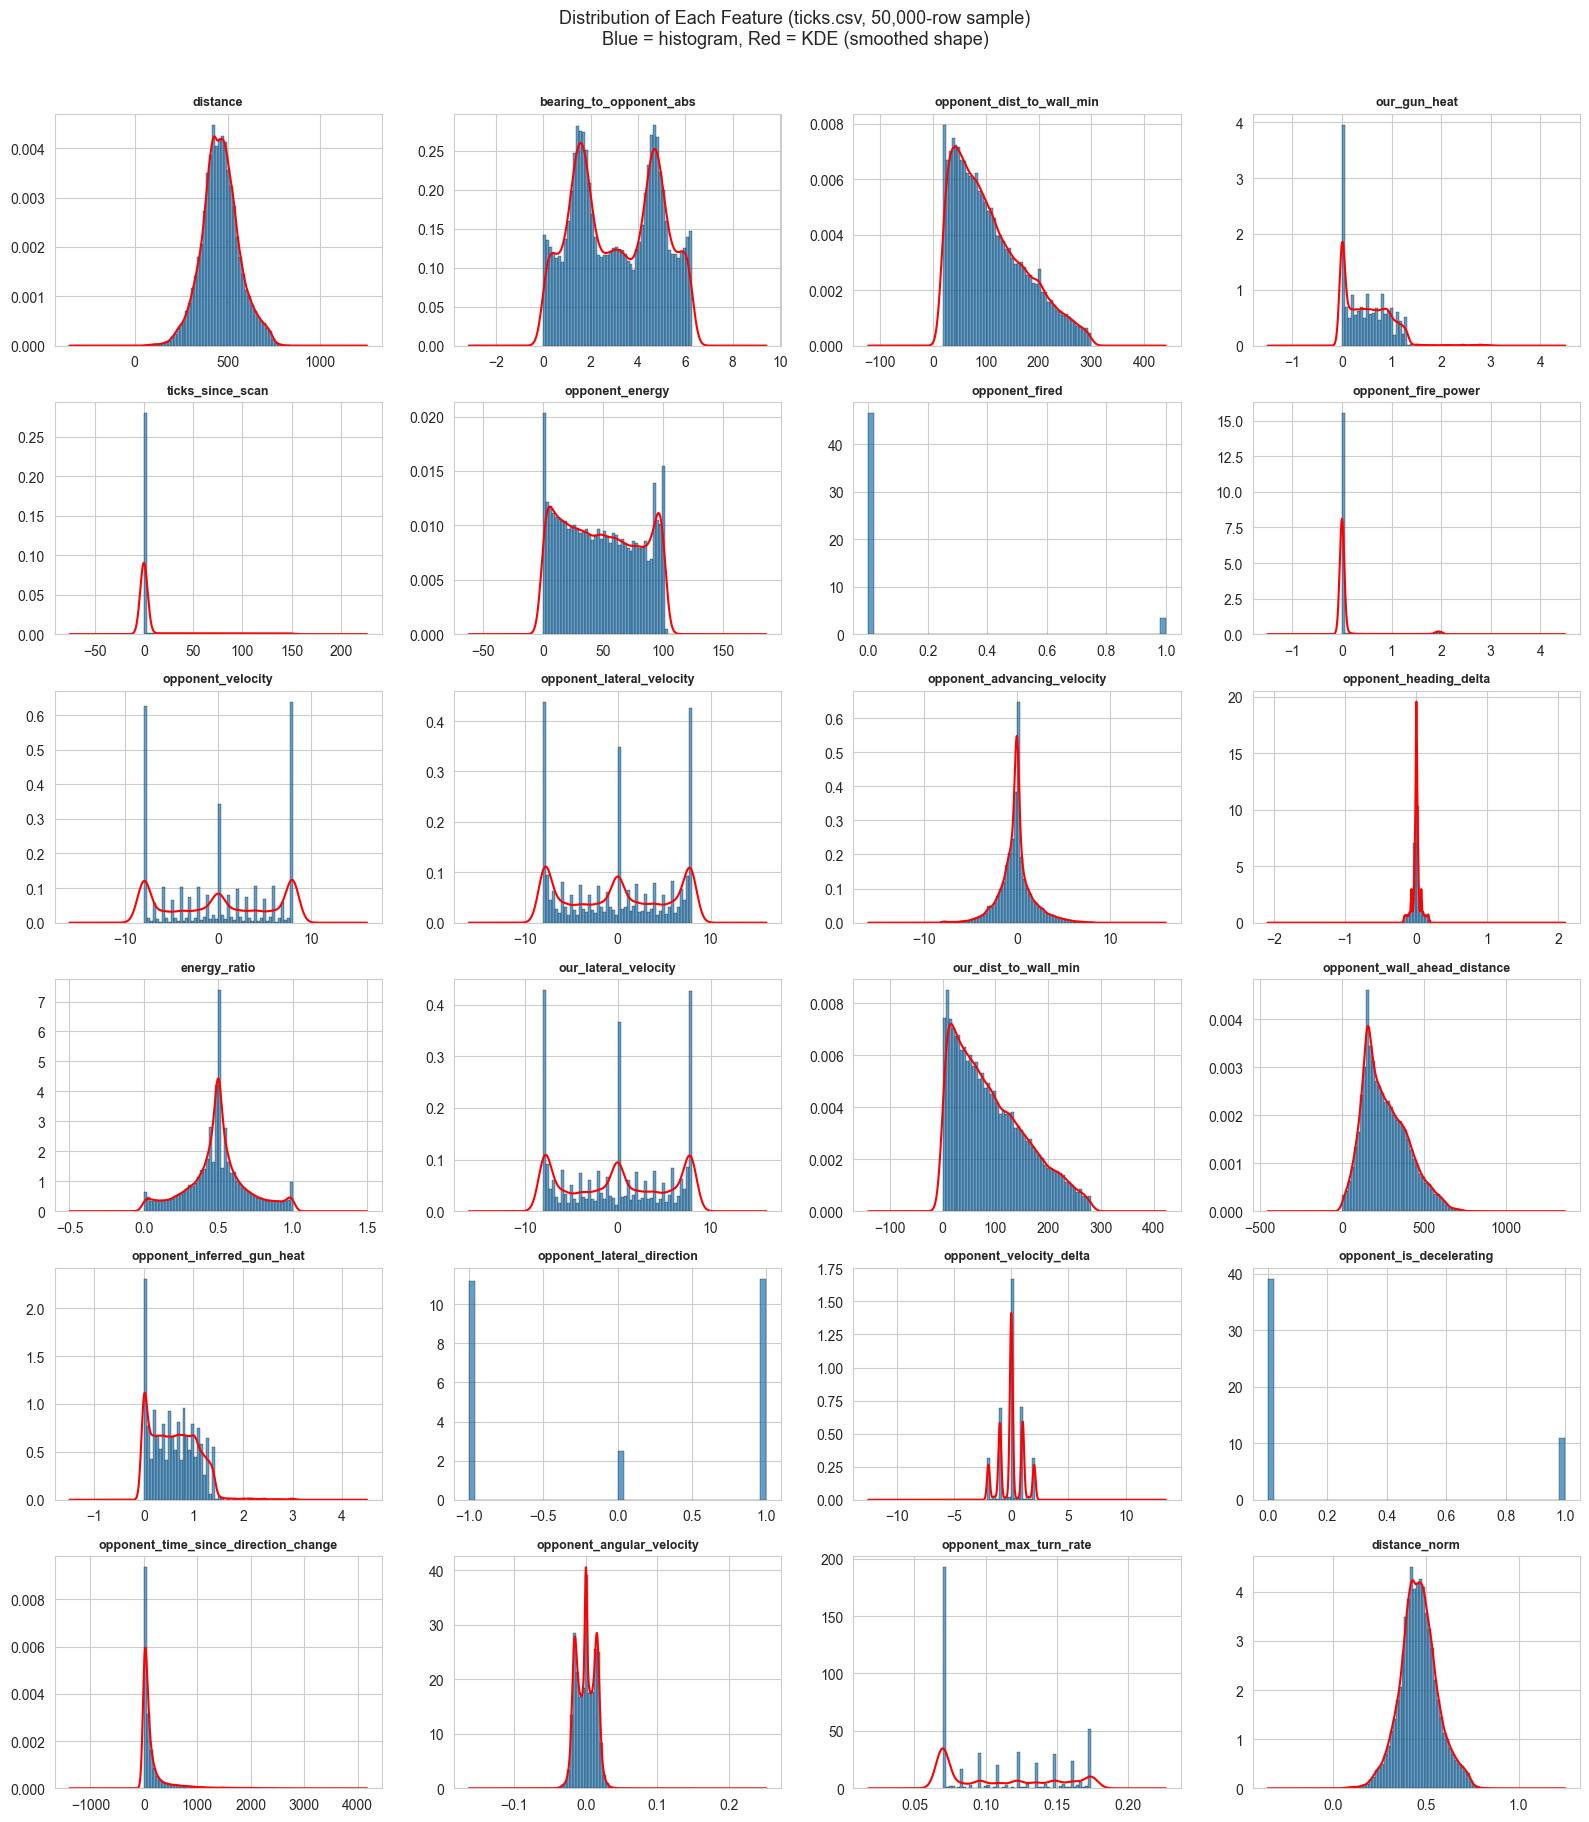

In [ ]:
# --- Histograms of all numeric features in ticks.csv ---
# Plotting on the full ~1M-row frame is overkill: a 50-bin histogram looks the
# same with 50,000 points as with 1,000,000. We subsample once for plotting.
# Use the shared exclude list — it covers row keys plus per-battle constants
# (battlefield size, gun cooling, identity hashes) that live in scores.csv now.
from _loader import numeric_feature_cols
feature_cols = numeric_feature_cols(ticks)

PLOT_SAMPLE = 50_000
plot_df = ticks[feature_cols].sample(min(PLOT_SAMPLE, len(ticks)),
                                     random_state=42)

n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = plot_df[col].dropna()
    if len(data) > 0:
        ax.hist(data, bins=50, alpha=0.7, edgecolor='black',
                linewidth=0.3, density=True)
        # KDE only if the column actually varies (avoid singular-matrix errors)
        if data.nunique() > 5 and data.std() > 1e-6:
            try:
                data.plot.kde(ax=ax, color='red', linewidth=1.5)
            except Exception:
                pass
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Distribution of Each Feature (ticks.csv, {PLOT_SAMPLE:,}-row sample)\n"
             f"Red curve = smoothed estimate of the distribution (KDE).",
             fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


## Section 5 — Box Plots per Robot

A **box plot** (also called "box and whisker") summarizes a distribution in 5 numbers:

```
         ┌─────────┐
    ─────┤   BOX   ├─────   ●  ●
         └─────────┘
   min  Q1  median  Q3  max  outliers
   (whisker)       (whisker)
```

- **The box** spans from Q1 (25th percentile) to Q3 (75th percentile) — the middle 50% of values
- **The line inside the box** is the median (50th percentile)
- **Whiskers** extend to 1.5 × IQR from the box edges (IQR = Q3 − Q1)
- **Dots beyond the whiskers** are outliers — unusually extreme values

Comparing boxes across robots tells us: does Diamond keep a different distance than BeepBoop? Does DrussGT move laterally more?

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(PER_ROBOT_SAMPLE, len(g)),
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


Box-plot sample: 100,000 rows (50 robots × ~2000 rows)


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_47456\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,


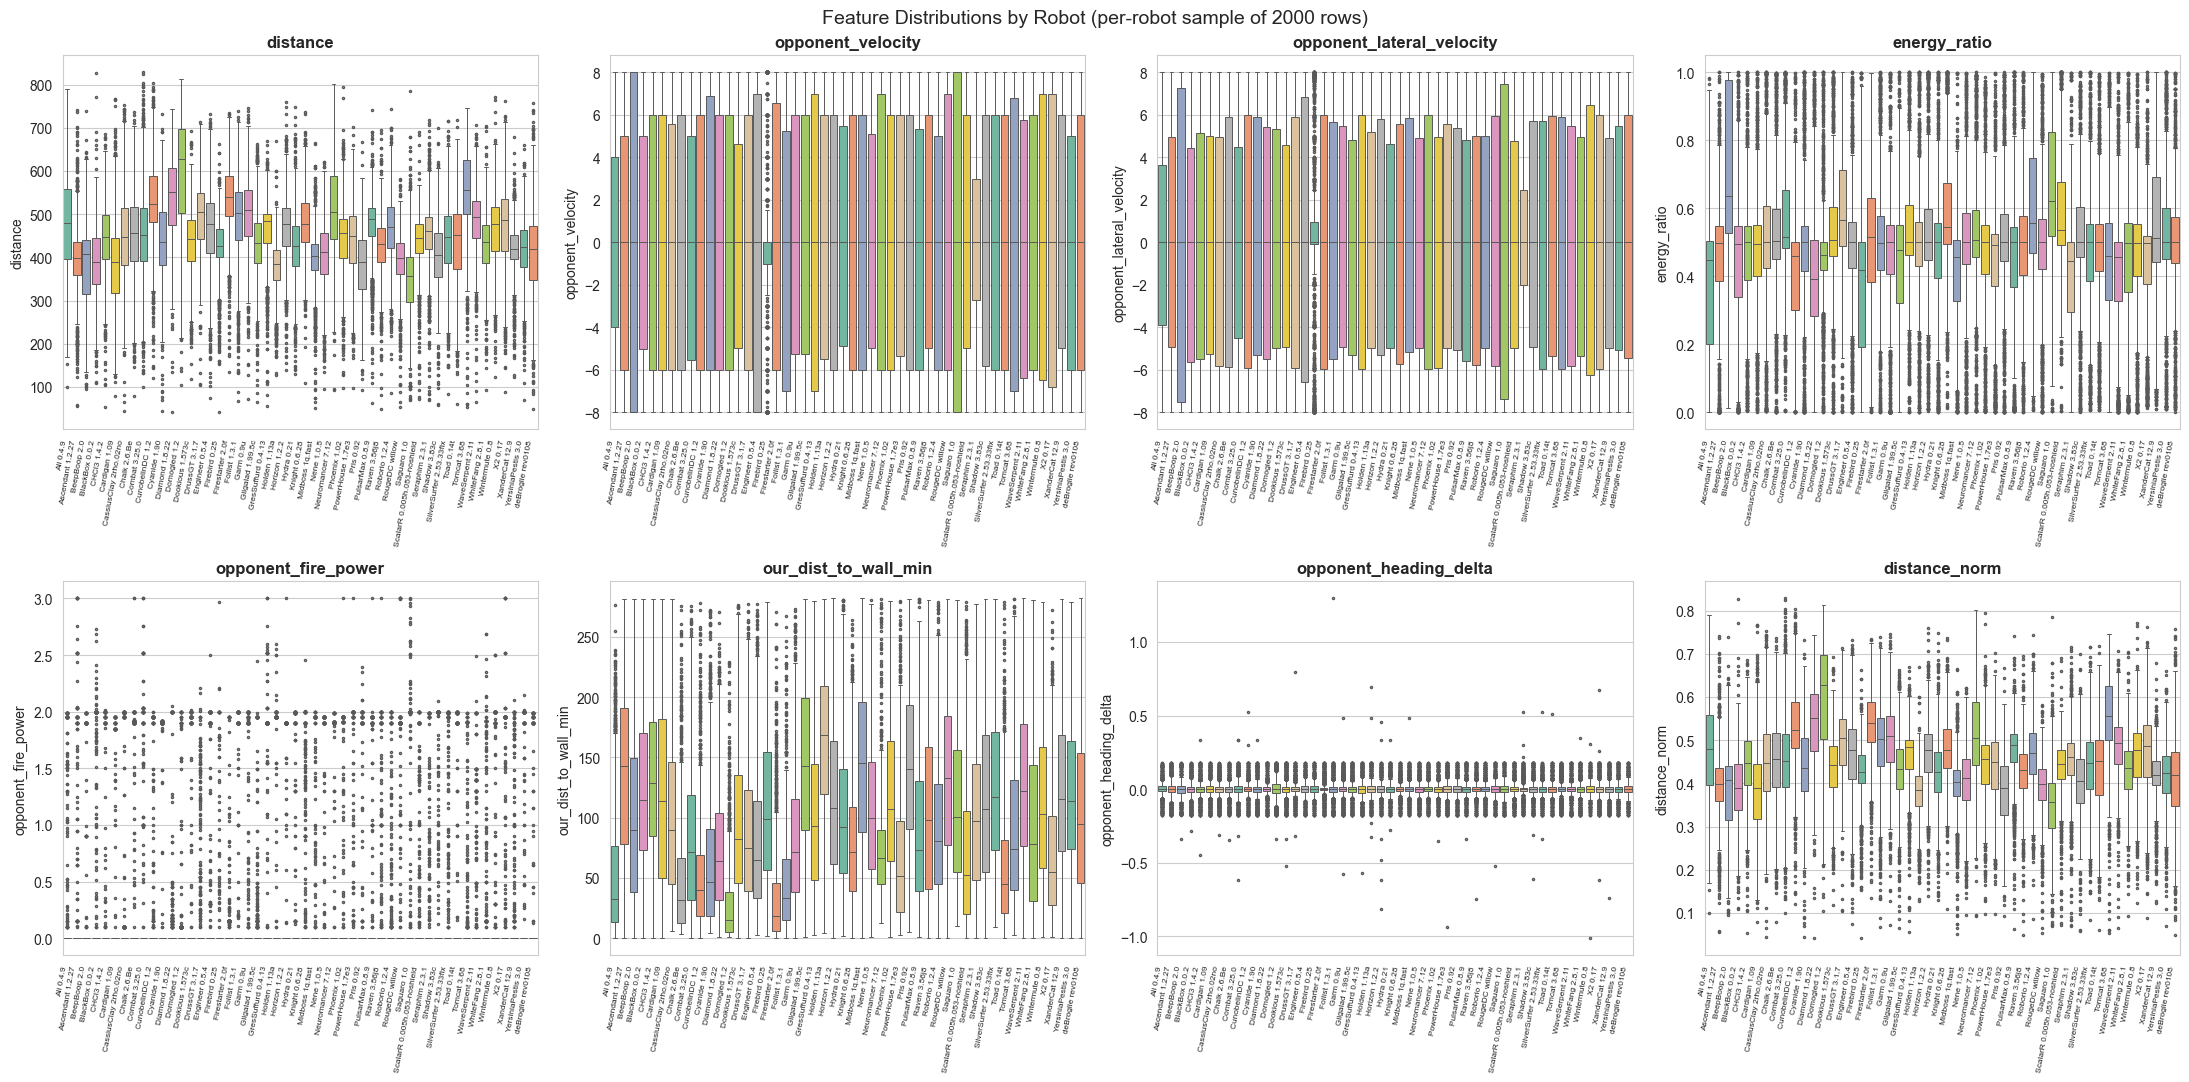

In [6]:
# --- Box plots of key features grouped by robot ---
# Subsample per robot so seaborn doesn't render millions of outlier glyphs.
key_features = ['distance', 'opponent_velocity', 'opponent_lateral_velocity',
                'energy_ratio', 'opponent_fire_power', 'our_dist_to_wall_min',
                'opponent_heading_delta', 'distance_norm']
key_features = [f for f in key_features if f in ticks.columns]

PER_ROBOT_SAMPLE = 2000
plot_ticks = (ticks.groupby('robot_name', group_keys=False)
                   .apply(lambda g: g.sample(min(PER_ROBOT_SAMPLE, len(g)),
                                             random_state=42)))
print(f"Box-plot sample: {len(plot_ticks):,} rows "
      f"({plot_ticks['robot_name'].nunique()} robots × ~{PER_ROBOT_SAMPLE} rows)")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if i >= len(axes):
        break
    ax = axes[i]
    data = plot_ticks[['robot_name', col]].dropna()
    if len(data) > 0:
        sns.boxplot(data=data, x='robot_name', y=col, ax=ax,
                    palette='Set2', fliersize=1.5, linewidth=0.7)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
                           ha='right', fontsize=6)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Robot "
             f"(per-robot sample of {PER_ROBOT_SAMPLE} rows)",
             fontsize=14)
plt.tight_layout()
plt.show()


## Section 6 — Time-Series: How a Battle Unfolds

Let's pick one battle and plot features over time. This shows the *dynamics* — how distance, energy, and other features change tick by tick.

Round boundaries are marked with vertical dashed lines.

Battle: 01eb4461
Robots: ['Shadow 3.83c']


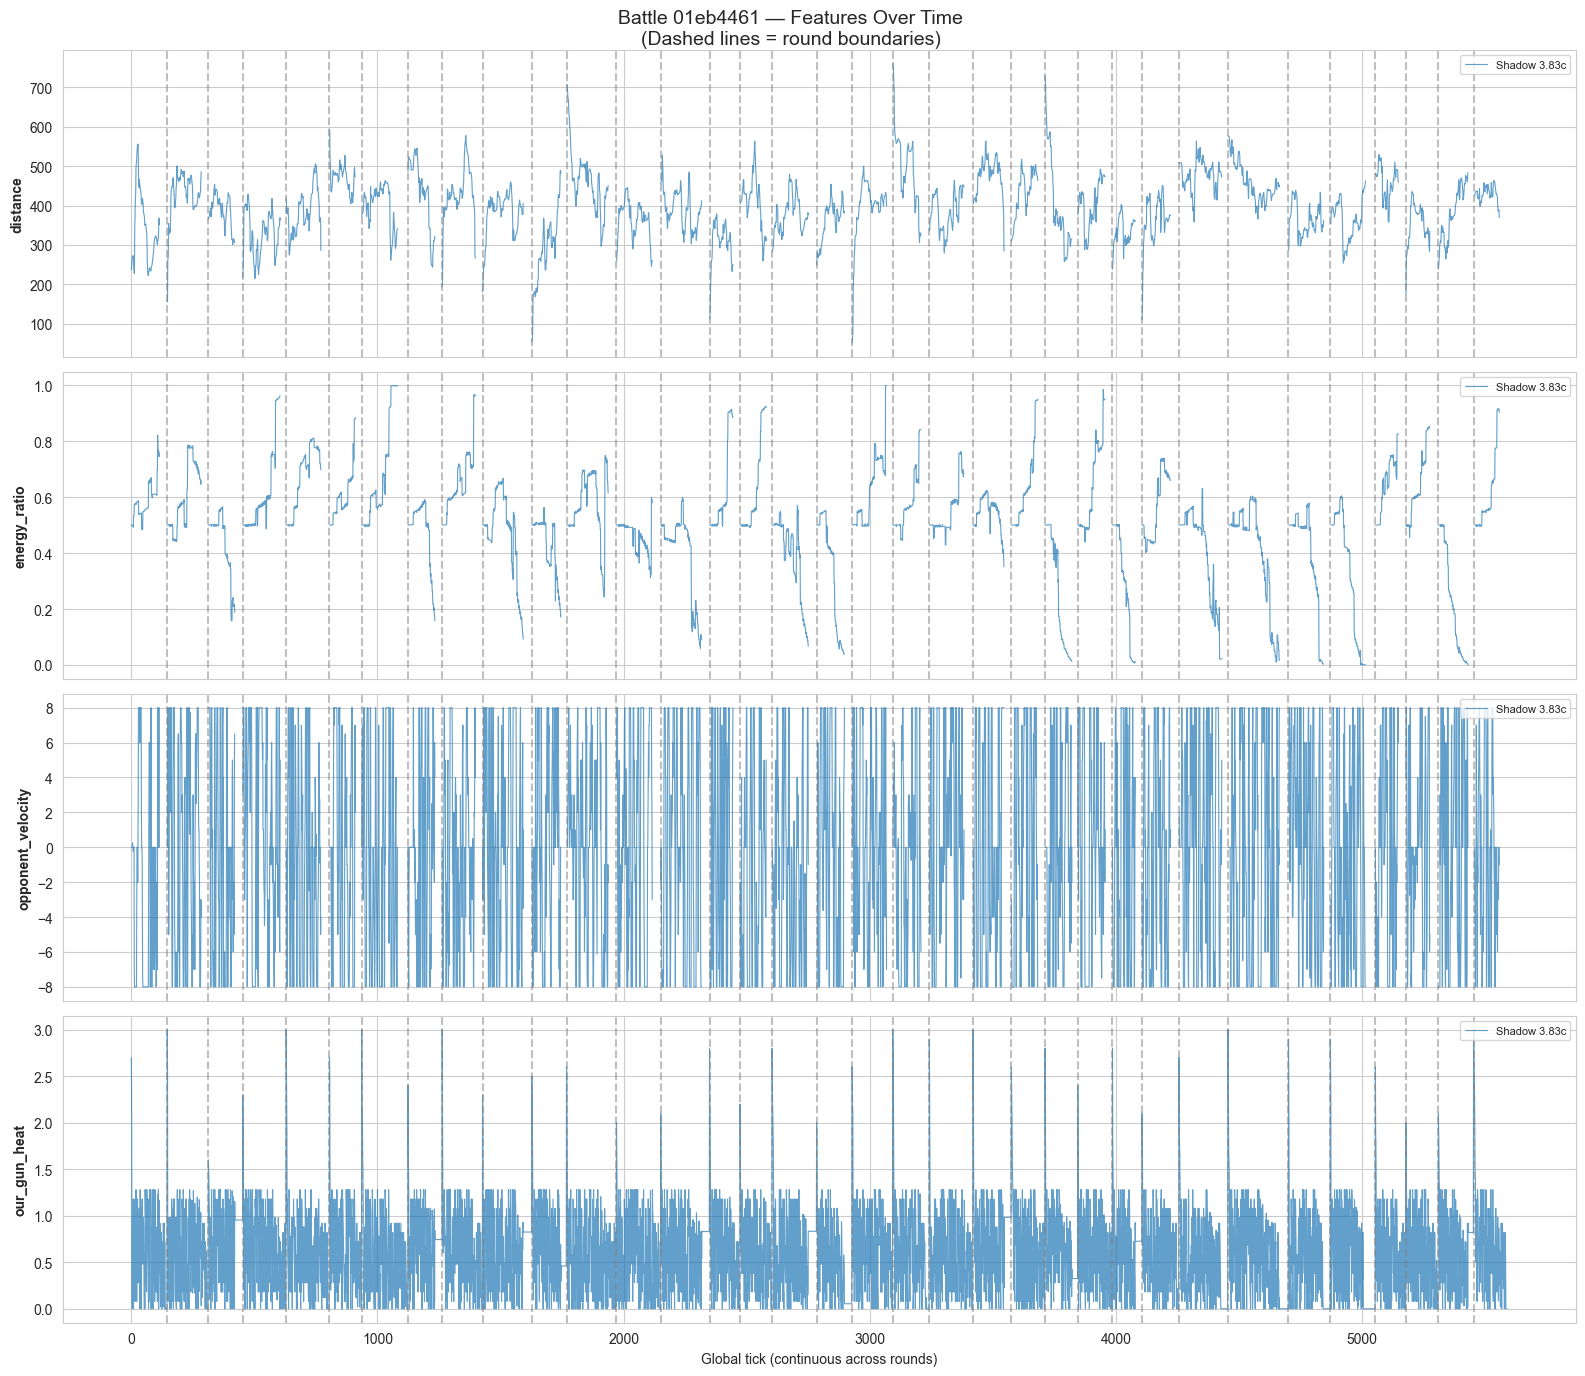

In [7]:
# --- Time series of one battle ---
# Pick the first battle_id
first_battle = ticks['battle_id'].unique()[0]
battle_data = ticks[ticks['battle_id'] == first_battle].copy()
robots_in_battle = battle_data['robot_name'].unique()

print(f"Battle: {first_battle}")
print(f"Robots: {robots_in_battle}")

# Create a continuous tick index (tick resets each round, so we make a global index)
battle_data = battle_data.sort_values(['robot_name', 'round', 'tick'])
battle_data['global_tick'] = battle_data.groupby('robot_name').cumcount()

time_features = ['distance', 'energy_ratio', 'opponent_velocity', 'our_gun_heat']
time_features = [f for f in time_features if f in battle_data.columns]

fig, axes = plt.subplots(len(time_features), 1, figsize=(16, 3.5 * len(time_features)), sharex=True)
if len(time_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, time_features):
    for robot in robots_in_battle:
        rdata = battle_data[battle_data['robot_name'] == robot]
        ax.plot(rdata['global_tick'], rdata[feat], label=robot, alpha=0.7, linewidth=0.8)
    
    # Mark round boundaries
    for robot in robots_in_battle[:1]:  # Use first robot for boundaries
        rdata = battle_data[battle_data['robot_name'] == robot]
        round_starts = rdata.groupby('round')['global_tick'].min()
        for rs in round_starts.values[1:]:  # Skip first round start
            ax.axvline(x=rs, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_ylabel(feat, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Global tick (continuous across rounds)")
fig.suptitle(f"Battle {first_battle} — Features Over Time\n(Dashed lines = round boundaries)", fontsize=14)
plt.tight_layout()
plt.show()

## Section 7 — Waves & Scores Overview

Quick look at bullet patterns and round outcomes.

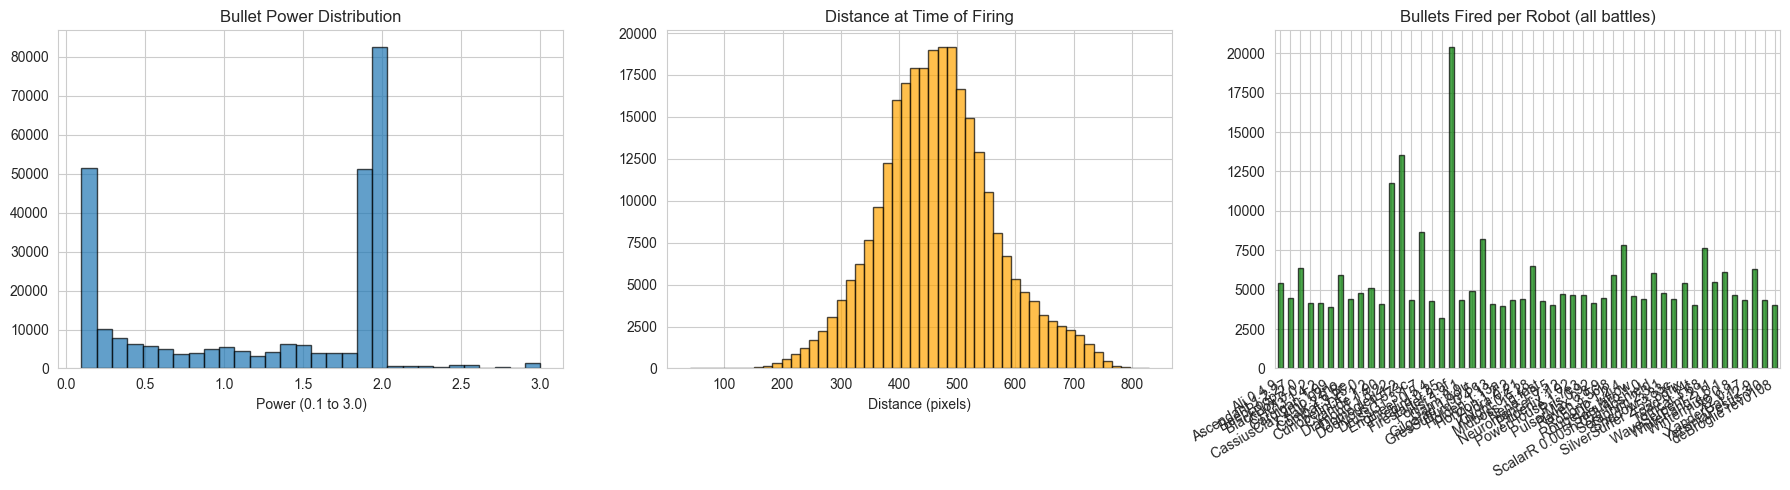

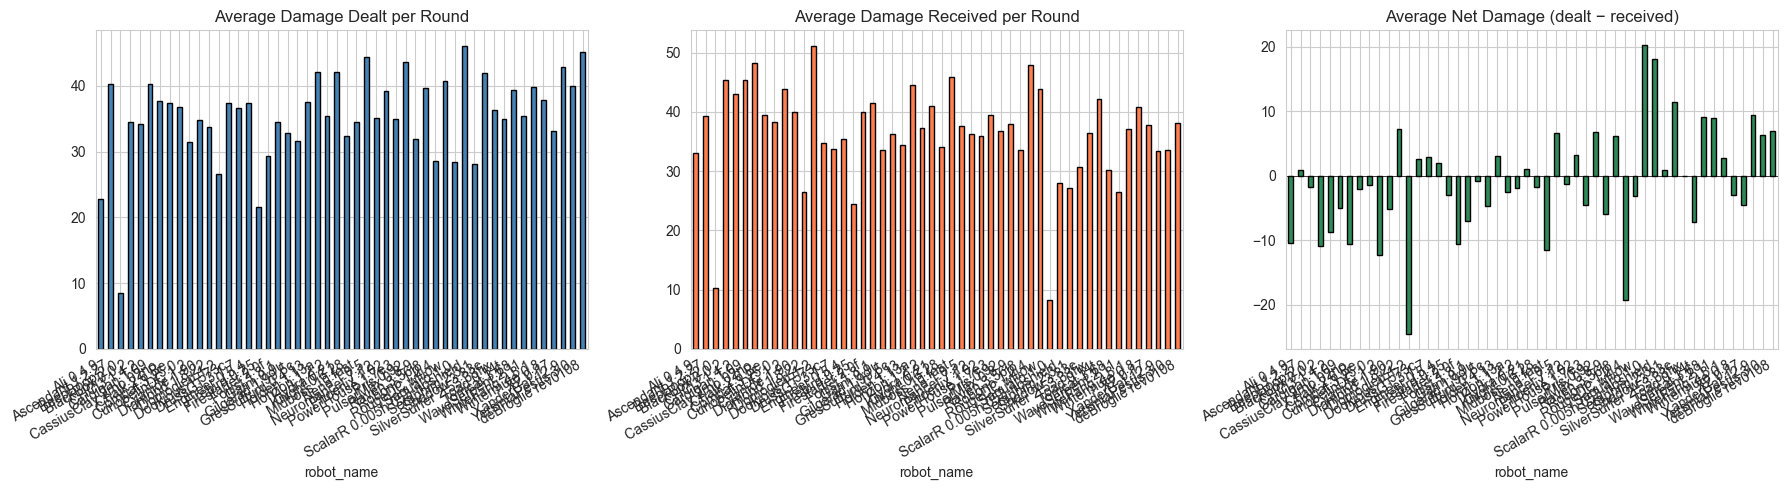

In [8]:
# --- Waves analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bullet power distribution
if 'wave_bullet_power' in waves.columns:
    axes[0].hist(waves['wave_bullet_power'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title("Bullet Power Distribution")
    axes[0].set_xlabel("Power (0.1 to 3.0)")

# Fire distance distribution
if 'wave_fire_distance' in waves.columns:
    axes[1].hist(waves['wave_fire_distance'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title("Distance at Time of Firing")
    axes[1].set_xlabel("Distance (pixels)")

# Waves per robot  
wave_counts = waves.groupby('robot_name').size()
wave_counts.plot.bar(ax=axes[2], color='green', edgecolor='black', alpha=0.7)
axes[2].set_title("Bullets Fired per Robot (all battles)")
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# --- Scores analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Damage dealt per robot
scores.groupby('robot_name')['damage_dealt'].mean().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Average Damage Dealt per Round")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Damage received per robot
scores.groupby('robot_name')['damage_received'].mean().plot.bar(
    ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title("Average Damage Received per Round")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# Net damage (positive = winning)
scores.groupby('robot_name')['net_damage'].mean().plot.bar(
    ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title("Average Net Damage (dealt − received)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()